In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


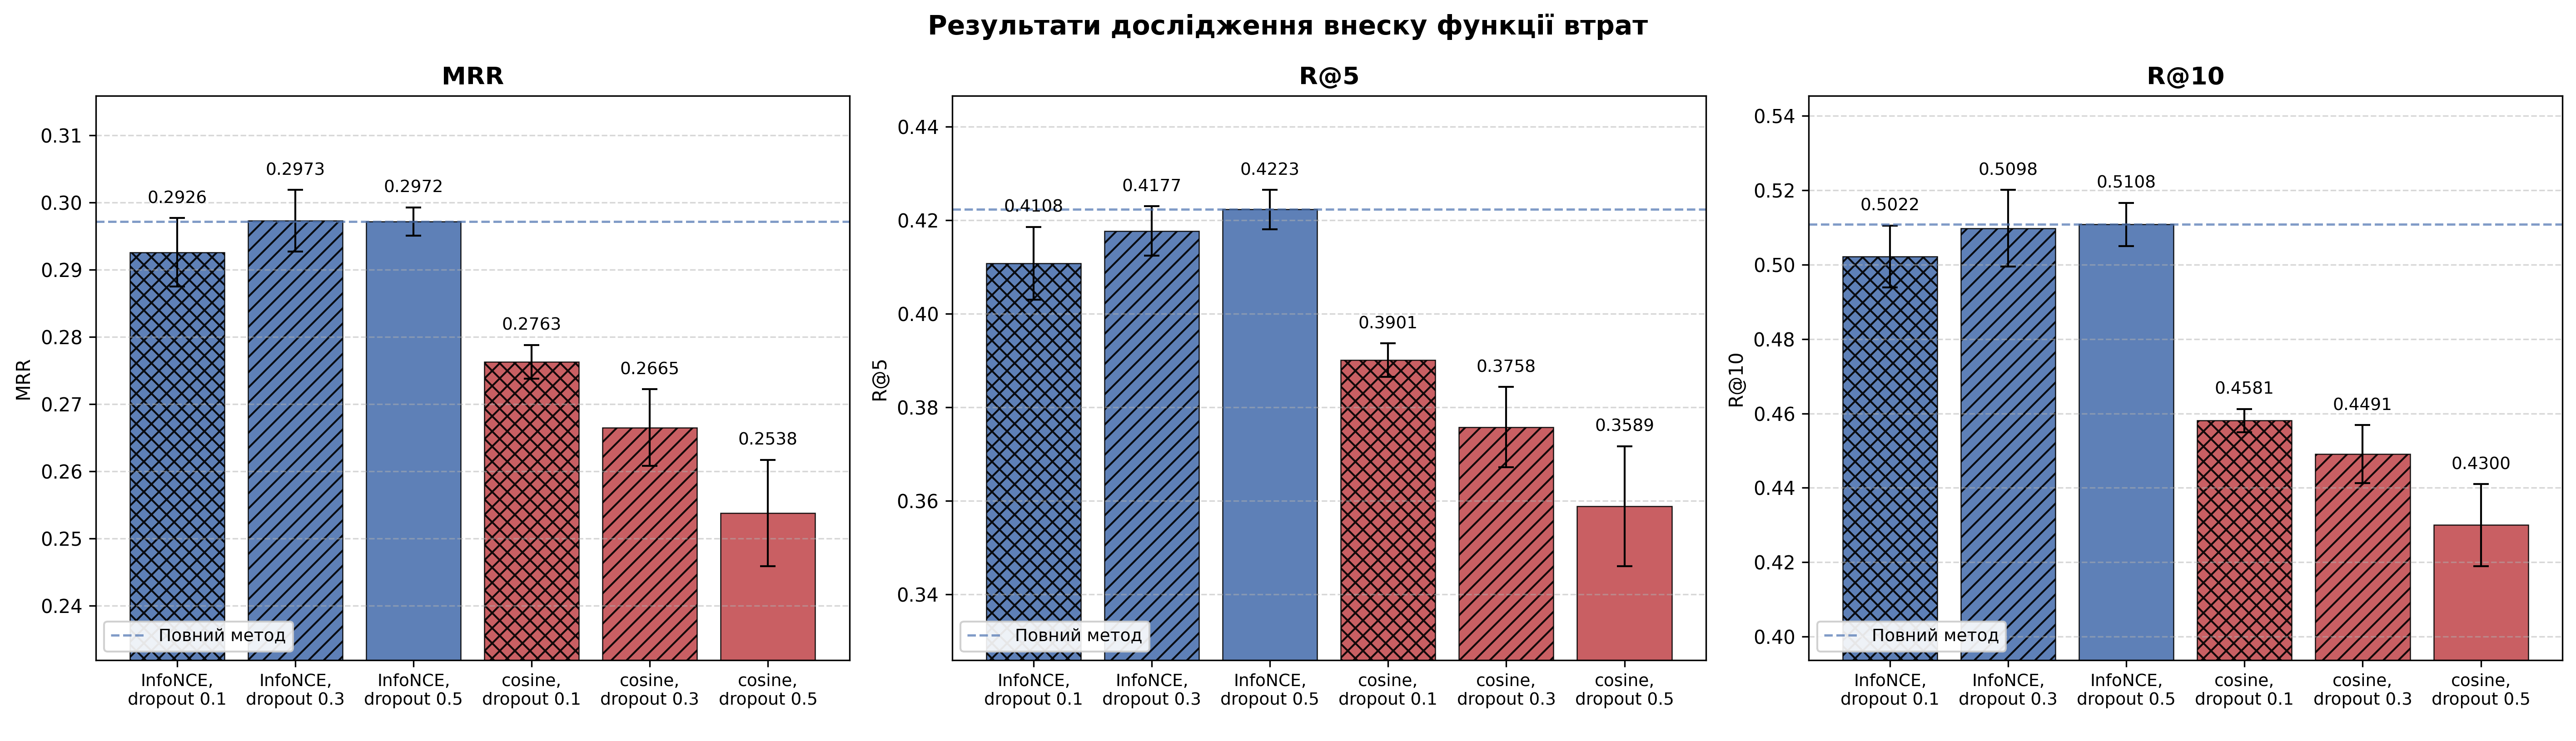

In [2]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    'InfoNCE,\ndropout 0.1',
    'InfoNCE,\ndropout 0.3',
    'InfoNCE,\ndropout 0.5\n',
    'cosine,\ndropout 0.1',
    'cosine,\ndropout 0.3',
    'cosine,\ndropout 0.5',
]

full_idx = 2

mrr      = np.array([0.2926, 0.2973, 0.2972, 0.2763, 0.2665, 0.2538])
mrr_std  = np.array([0.0051, 0.0046, 0.0021, 0.0025, 0.0057, 0.0079])

r5       = np.array([0.4108, 0.4177, 0.4223, 0.3901, 0.3758, 0.3589])
r5_std   = np.array([0.0078, 0.0053, 0.0042, 0.0036, 0.0086, 0.0128])

r10      = np.array([0.5022, 0.5098, 0.5108, 0.4581, 0.4491, 0.4300])
r10_std  = np.array([0.0083, 0.0103, 0.0058, 0.0031, 0.0078, 0.0110])

metrics = [
    ('MRR',  mrr, mrr_std),
    ('R@5',  r5,  r5_std),
    ('R@10', r10, r10_std),
]

infonce_color = '#4C72B0'
cosine_color  = '#C44E52'
colors  = [infonce_color, infonce_color, infonce_color, cosine_color, cosine_color, cosine_color]
hatches = ['xxx',         '///',         '',            'xxx',         '///',         '']

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), dpi=300)
x = np.arange(len(methods))

for ax, (name, vals, errs) in zip(axes, metrics):
    bars = ax.bar(x, vals, yerr=errs, capsize=4, color=colors,
                  edgecolor='black', linewidth=0.6, hatch=hatches, alpha=0.9,
                  error_kw={'ecolor': 'black', 'elinewidth': 1.0})

    full_val = vals[full_idx]
    ax.axhline(full_val, color=infonce_color, linestyle='--',
               linewidth=1.2, alpha=0.7, label='Повний метод')

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=9)
    ax.set_ylabel(name)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    lo = float((vals - errs).min())
    hi = float((vals + errs).max())
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    for bar, v, e in zip(bars, vals, errs):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + e + (hi - lo) * 0.03,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

    ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

fig.suptitle('Результати дослідження внеску функції втрат',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()